In [26]:
# Plot RelCAGR vs Delta ELBO and vs CPLL, CPLL Gap
# Smooth CPLL: conditional predictive log-likelihood; out-of-sample accuracy # Smooth CPLL: overestimates OOS accuracy due to look-ahead bias
# ELBO: Evidence lower bound; lower bound on the true log-likelihood (lowest start minus highest end accross all runs)

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import adjusted_rand_score as _ARI

In [28]:
# params
vmin_cagr, vmax_cagr = -0.10, 0.10
vmax_cpll = 200000
vmax_elbo = 1000000

In [29]:
# import data
filename_results = '/Users/chrismader/Python/SLDS/Results/gridsearch_results.csv'
filename_static = '/Users/chrismader/Python/SLDS/Data/static_data.csv'
res = pd.read_csv(filename_results)
static = pd.read_csv(filename_static, usecols=[0,1,2])

In [30]:
# Prep data
res['sector'] = res['security'].map(static.set_index('Ticker')['SectorID'])
res['CPLL Gap'] = res['max cpll (proxy bound, paired)'] - res['cpll (max all runs)']
res.insert(res.columns.get_loc('security') + 1, 'sector', res.pop('sector'))
res = res[np.isfinite(pd.to_numeric(res['cagr_rel_ex_ante'], errors='coerce'))].copy()
res = res[np.isfinite(pd.to_numeric(res['score'], errors='coerce'))].copy()

print(list(np.unique(res.config)))
print(list(np.unique(res.sector)))
print(list(np.unique(res.security)))
print(res.columns)

# Settings
configs = np.unique(res.config)
unrestricted = [x for x in configs if x.startswith('[')]
restricted = [x for x in configs if not x.startswith('[')]
print(unrestricted)
print(restricted)

['[g,v,h]', '[g,v]', '[y,g,v,h]', '[y,h]', '[y]', 'factor1', 'factor1_vix', 'factor2_ff3', 'factor2_ff3mom', 'factor2_ff5', 'factor2_ff5mom', 'fund1', 'fund1_vix', 'fund2', 'fund2_vix', 'fund3', 'fund3_vix']
['CD', 'CS', 'EN', 'FN', 'HC', 'IN', 'IT', 'MT', 'RL', 'TC', 'UT']
['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AEP', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BSX', 'C', 'CAT', 'CBRE', 'COST', 'CRM', 'CSCO', 'CVX', 'D', 'DIS', 'DUK', 'EQIX', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'IBM', 'INTU', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'MA', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NOW', 'NVDA', 'O', 'ORCL', 'PEP', 'PG', 'PGR', 'PLD', 'PM', 'QCOM', 'RTX', 'SCHW', 'SO', 'SPGI', 'T', 'TMO', 'TSLA', 'TXN', 'UNH', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
Index(['security', 'sector', 'config', 'rank', 'score', 'dt', 'n_regimes',
       'dim_latent', 'single_subspace', 'train_window', 'overlap_window',
       'avg_inferred_regime_length', 'elbo_start (min

In [31]:
# Helpers

def performance(df, value_sel):
    
    idx = ['config','n_regimes','dim_latent']
    sector_cols = sorted(df['sector'].unique())
    
    # sector means
    pt = (df.pivot_table(index=idx, columns='sector', values=value_sel, aggfunc='mean')
            .sort_index().reindex(sector_cols, axis=1))
    
    # true stats across ALL securities (not avg of sectors)
    stats = (df.groupby(idx)[value_sel]
               .agg(avg='mean', std='std', min='min', max='max'))
    stats['range'] = stats['max'] - stats['min']
    
    # join, order, sort
    finite_mask = np.isfinite(pt.to_numpy()).all(axis=1)
    pt_sel = (pt.loc[finite_mask]
                .join(stats, how='left')
                .loc[:, sector_cols + ['avg','std','min','max','range']]
                .sort_values('avg', ascending=False))
    
    # style
    styled = (pt_sel.style
               .format('{:.3f}')
               .background_gradient(cmap='RdBu', vmin=vmin_cagr, vmax=vmax_cagr,
                                    subset=sector_cols + ['avg'])
               .highlight_null())
    
    # lock in order
    base_idx  = pt_sel.index                                 # exact rows + order
    cols_tail = ['avg','std','min','max','range']            # trailing stats
    cols_all = sector_cols + cols_tail                      # exact columns

    return styled, base_idx, cols_tail, cols_all

def performance_securities(df, value_sel, base_idx):
    """Rows = (config, n_regimes, dim_latent).
    Cols = (sector, security). Styled. No right-hand stats."""
    idx = ['config','n_regimes','dim_latent']
    tbl = (df.pivot_table(index=idx,
                          columns=['sector','security'],
                          values=value_sel,
                          aggfunc='mean')
             .sort_index(axis=1)
             .reindex(base_idx))   # preserve exact row order

    styled = (tbl.style
                .format('{:.3f}')
                .background_gradient(cmap='RdBu',
                                     vmin=vmin_cagr, vmax=vmax_cagr)
                .highlight_null())
    return styled

def _metric_table_core(value_sel, df, base_idx, cols_tail, cols_all):
    idx = list(base_idx.names)
    sector_cols = [c for c in cols_all if c not in cols_tail]

    pt_m = (
        df.pivot_table(index=idx, columns='sector', values=value_sel, aggfunc='mean')
          .reindex(sector_cols, axis=1)
          .reindex(base_idx)
    )

    stats_m = (
        df.groupby(idx)[value_sel]
          .agg(avg='mean', std='std', min='min', max='max')
          .reindex(base_idx)
    )
    stats_m['range'] = stats_m['max'] - stats_m['min']

    tbl = pd.concat([pt_m, stats_m[cols_tail]], axis=1).reindex(columns=cols_all)

    # this is what you wanted: expose the max of the colored cols
    data_max = tbl[sector_cols + ['avg']].to_numpy().max()

    return tbl, sector_cols, float(data_max)

def cpll_table(df, base_idx, cols_tail, cols_all,
               vmax=None, fmt='{:,.1f}'):
    value_sel = 'CPLL Gap'
    tbl, sector_cols, data_max = _metric_table_core(
        value_sel, df, base_idx, cols_tail, cols_all
    )
    vmin = 0.0
    if vmax is None:
        vmax = data_max

    return (tbl.style
                .format(fmt)
                .background_gradient(
                    cmap='Reds',
                    vmin=vmin,
                    vmax=vmax,
                    subset=sector_cols + ['avg'],
                )
                .highlight_null())


def elbo_table(df, base_idx, cols_tail, cols_all,
               vmax=None, fmt='{:,.1f}'):
    value_sel = 'elbo_delta (max all runs)'
    tbl, sector_cols, data_max = _metric_table_core(
        value_sel, df, base_idx, cols_tail, cols_all
    )
    vmin = 0.0
    if vmax is None:
        vmax = data_max

    return (tbl.style
                .format(fmt)
                .background_gradient(
                    cmap='Blues',     # high → blue
                    vmin=vmin,
                    vmax=vmax,
                    subset=sector_cols + ['avg'],
                )
                .highlight_null())

# Formatting
CAPTION_CSS = [{'selector': 'caption',
                'props': [('caption-side','top'),
                          ('text-align','left'),
                          ('font-weight','700')]}]

In [32]:
# Model performance - unrestricted
df_unrestr = res[res['config'].isin(unrestricted)]
df_unrestr.to_csv('Out/df_unrestr.csv')
styled_unrestr, base_idx_unrestr, cols_tail_unrestr, cols_all_unrestr = performance(df_unrestr, 'cagr_rel_ex_ante')
styled_unrestr.set_caption("Rel CAGR - Unrestricted Models")
styled_unrestr.set_table_styles(CAPTION_CSS, overwrite=False)
styled_unrestr.data.to_csv('Out/unrestr_rel_cagr.csv')
styled_unrestr

In [33]:
styled_unrestr_securities = performance_securities(df_unrestr, 'cagr_rel_ex_ante', base_idx_unrestr)
styled_unrestr_securities.data.to_csv('Out/unrestr_rel_cagr_securities.csv')
# styled_unrestr_securities

In [34]:
# Smooth CPLL - unrestricted
styled_cpll_all = cpll_table(
    df_unrestr,
    base_idx_unrestr,
    cols_tail_unrestr,
    cols_all_unrestr,
    vmax=vmax_cpll,
)
styled_cpll_all = (
    styled_cpll_all
    .set_caption("Smooth CPLL Gap - Unrestricted Models")
    .set_table_styles(CAPTION_CSS, overwrite=False)
)
styled_cpll_all.data.to_csv('Out/unrestr_cpll_gap.csv')
styled_cpll_all

In [35]:
# Delta ELBO - unrestricted
styled_elbo_all = elbo_table(
    df_unrestr,
    base_idx_unrestr,
    cols_tail_unrestr,
    cols_all_unrestr,
    vmax=vmax_elbo,
)
styled_elbo_all = (
    styled_elbo_all
    .set_caption("Delta ELBO - Unrestricted Models")
    .set_table_styles(CAPTION_CSS, overwrite=False)
)
styled_elbo_all.data.to_csv('Out/unrestr_delta_elbo.csv')
styled_elbo_all

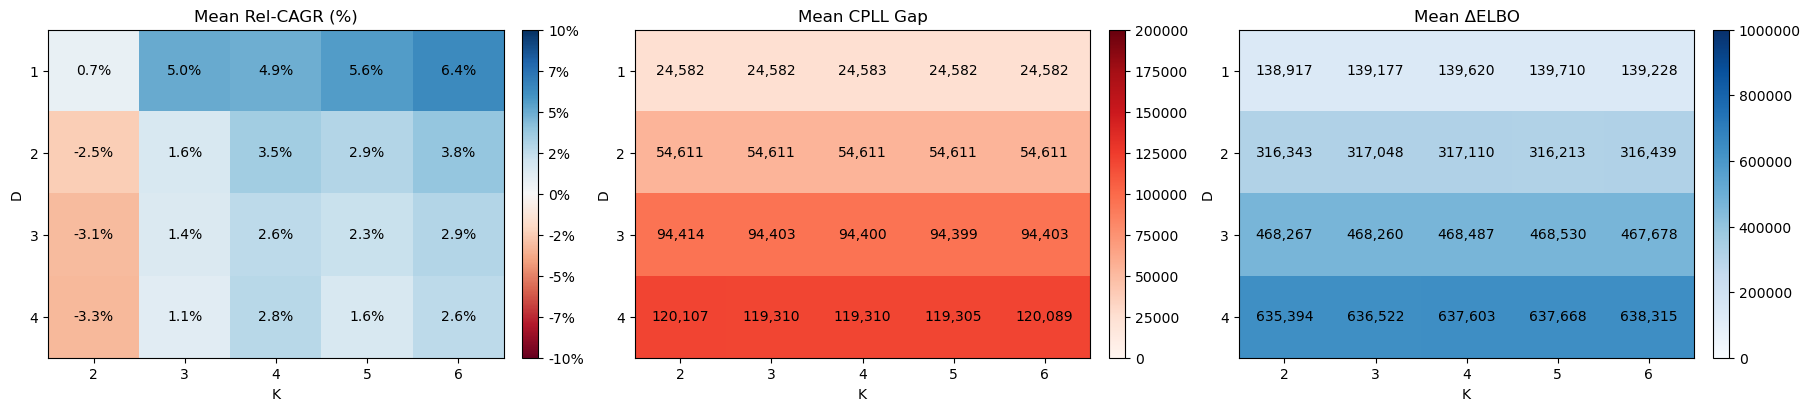

In [36]:
# Unrestricted models: heatmaps

if 'CPLL Gap' not in res.columns:
    res['CPLL Gap'] = res['max cpll (proxy bound, paired)'] - res['cpll (max all runs)']

configs = np.unique(res['config'])
unrestricted = [x for x in configs if str(x).startswith('[')]
df = res[res['config'].isin(unrestricted)].copy()

finite = (
    pd.to_numeric(df['cagr_rel_ex_ante'], errors='coerce').notna()
    & pd.to_numeric(df['CPLL Gap'], errors='coerce').notna()
    & pd.to_numeric(df['elbo_delta (max all runs)'], errors='coerce').notna()
    & pd.to_numeric(df['n_regimes'], errors='coerce').notna()
    & pd.to_numeric(df['dim_latent'], errors='coerce').notna()
)
df = df.loc[finite].copy()

m = (df.groupby(['n_regimes','dim_latent'], as_index=False)
         .agg(rel_cagr=('cagr_rel_ex_ante','mean'),
              cpll_gap=('CPLL Gap','mean'),
              delta_elbo=('elbo_delta (max all runs)','mean')))

# Multiply CAGR by 100 to express as percentage
m['rel_cagr'] *= 100

def pivotKD(frame, value):
    p = frame.pivot(index='dim_latent', columns='n_regimes', values=value)
    return p.sort_index().sort_index(axis=1)

def _annotate(ax, Z, fmt):
    """Write value inside each heatmap cell."""
    nrows, ncols = Z.shape
    for i in range(nrows):
        for j in range(ncols):
            v = Z[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt(v), ha='center', va='center')

# Pivots
pivot_cagr = pivotKD(m, 'rel_cagr')
pivot_gap  = pivotKD(m, 'cpll_gap')
pivot_elbo = pivotKD(m, 'delta_elbo')


# ---------------- Rel-CAGR % | CPLL Gap | ΔELBO — single figure ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# ---- Rel-CAGR (%)
im0 = axes[0].imshow(pivot_cagr, aspect='auto', cmap='RdBu', vmin=vmin_cagr*100, vmax=vmax_cagr*100)
axes[0].set_title("Mean Rel-CAGR (%)")
axes[0].set_xlabel('K'); axes[0].set_ylabel('D')
axes[0].set_xticks(range(len(pivot_cagr.columns))); axes[0].set_xticklabels(pivot_cagr.columns)
axes[0].set_yticks(range(len(pivot_cagr.index)));   axes[0].set_yticklabels(pivot_cagr.index)
_annotate(axes[0], pivot_cagr.values, fmt=lambda v: f"{v:.1f}%")
fig.colorbar(im0, ax=axes[0], format='%d%%', fraction=0.046, pad=0.04)

# ---- CPLL Gap
im1 = axes[1].imshow(pivot_gap, aspect='auto', cmap='Reds', vmin=0.0, vmax=vmax_cpll)
axes[1].set_title("Mean CPLL Gap")
axes[1].set_xlabel('K'); axes[1].set_ylabel('D')
axes[1].set_xticks(range(len(pivot_gap.columns))); axes[1].set_xticklabels(pivot_gap.columns)
axes[1].set_yticks(range(len(pivot_gap.index)));   axes[1].set_yticklabels(pivot_gap.index)
_annotate(axes[1], pivot_gap.values, fmt=lambda v: f"{v:,.0f}")
fig.colorbar(im1, ax=axes[1], format='%d', fraction=0.046, pad=0.04)

# ---- ΔELBO
im2 = axes[2].imshow(pivot_elbo, aspect='auto', cmap='Blues', vmin=0.0, vmax=vmax_elbo)
axes[2].set_title("Mean ΔELBO")
axes[2].set_xlabel('K'); axes[2].set_ylabel('D')
axes[2].set_xticks(range(len(pivot_elbo.columns))); axes[2].set_xticklabels(pivot_elbo.columns)
axes[2].set_yticks(range(len(pivot_elbo.index)));   axes[2].set_yticklabels(pivot_elbo.index)
_annotate(axes[2], pivot_elbo.values, fmt=lambda v: f"{v:,.0f}")
fig.colorbar(im2, ax=axes[2], format='%d', fraction=0.046, pad=0.04)

plt.show()



In [37]:
# Model performance - restricted
df_restr = res[res['config'].isin(restricted)]
styled_restr, base_idx_restr, cols_tail_restr, cols_all_restr = performance(
    df_restr, 'cagr_rel_ex_ante'
)
styled_restr = (
    styled_restr
    .set_caption("Rel CAGR - Restricted Models")
    .set_table_styles(CAPTION_CSS, overwrite=False)
)
styled_restr.data.to_csv('Out/restr_rel_cagr.csv')
styled_restr

In [38]:
# Smooth CPLL - restricted
styled_cpll_all = cpll_table(
    df_restr,
    base_idx_restr,
    cols_tail_restr,
    cols_all_restr,
    vmax=vmax_cpll,
)
styled_cpll_all = (
    styled_cpll_all
    .set_caption("Smooth CPLL - Restricted Models")
    .set_table_styles(CAPTION_CSS, overwrite=False)
)
styled_cpll_all.data.to_csv('Out/restr_cpll_gap.csv')
styled_cpll_all

In [39]:
# Delta ELBO - restricted
styled_elbo_all = elbo_table(
    df_restr,
    base_idx_restr,
    cols_tail_restr,
    cols_all_restr,
    vmax=vmax_elbo,
)
styled_elbo_all = (
    styled_elbo_all
    .set_caption("Delta ELBO - Unrestricted Models")
    .set_table_styles(CAPTION_CSS, overwrite=False)
)
styled_elbo_all.data.to_csv('Out/restr_delta_elbo.csv')
styled_elbo_all

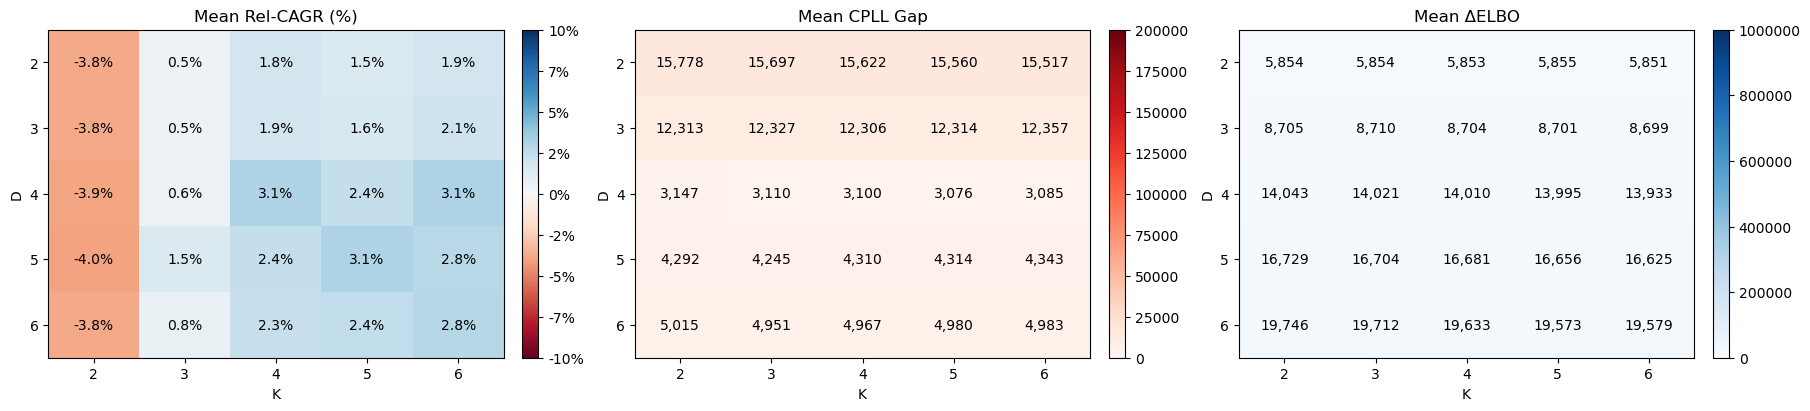

In [40]:
# Unrestricted models: heatmaps

if 'CPLL Gap' not in res.columns:
    res['CPLL Gap'] = res['max cpll (proxy bound, paired)'] - res['cpll (max all runs)']

configs = np.unique(res['config'])
restricted = [x for x in configs if not str(x).startswith('[')]
df = res[res['config'].isin(restricted)].copy()

finite = (
    pd.to_numeric(df['cagr_rel_ex_ante'], errors='coerce').notna()
    & pd.to_numeric(df['CPLL Gap'], errors='coerce').notna()
    & pd.to_numeric(df['elbo_delta (max all runs)'], errors='coerce').notna()
    & pd.to_numeric(df['n_regimes'], errors='coerce').notna()
    & pd.to_numeric(df['dim_latent'], errors='coerce').notna()
)
df = df.loc[finite].copy()

m = (df.groupby(['n_regimes','dim_latent'], as_index=False)
         .agg(rel_cagr=('cagr_rel_ex_ante','mean'),
              cpll_gap=('CPLL Gap','mean'),
              delta_elbo=('elbo_delta (max all runs)','mean')))

# Multiply CAGR by 100 to express as percentage
m['rel_cagr'] *= 100

def pivotKD(frame, value):
    p = frame.pivot(index='dim_latent', columns='n_regimes', values=value)
    return p.sort_index().sort_index(axis=1)

def _annotate(ax, Z, fmt):
    """Write value inside each heatmap cell."""
    nrows, ncols = Z.shape
    for i in range(nrows):
        for j in range(ncols):
            v = Z[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt(v), ha='center', va='center')

# Pivots
pivot_cagr = pivotKD(m, 'rel_cagr')
pivot_gap  = pivotKD(m, 'cpll_gap')
pivot_elbo = pivotKD(m, 'delta_elbo')


# ---------------- Rel-CAGR % | CPLL Gap | ΔELBO — single figure ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# ---- Rel-CAGR (%)
im0 = axes[0].imshow(pivot_cagr, aspect='auto', cmap='RdBu', vmin=vmin_cagr*100, vmax=vmax_cagr*100)
axes[0].set_title("Mean Rel-CAGR (%)")
axes[0].set_xlabel('K'); axes[0].set_ylabel('D')
axes[0].set_xticks(range(len(pivot_cagr.columns))); axes[0].set_xticklabels(pivot_cagr.columns)
axes[0].set_yticks(range(len(pivot_cagr.index)));   axes[0].set_yticklabels(pivot_cagr.index)
_annotate(axes[0], pivot_cagr.values, fmt=lambda v: f"{v:.1f}%")
fig.colorbar(im0, ax=axes[0], format='%d%%', fraction=0.046, pad=0.04)

# ---- CPLL Gap
im1 = axes[1].imshow(pivot_gap, aspect='auto', cmap='Reds', vmin=0.0, vmax=vmax_cpll)
axes[1].set_title("Mean CPLL Gap")
axes[1].set_xlabel('K'); axes[1].set_ylabel('D')
axes[1].set_xticks(range(len(pivot_gap.columns))); axes[1].set_xticklabels(pivot_gap.columns)
axes[1].set_yticks(range(len(pivot_gap.index)));   axes[1].set_yticklabels(pivot_gap.index)
_annotate(axes[1], pivot_gap.values, fmt=lambda v: f"{v:,.0f}")
fig.colorbar(im1, ax=axes[1], format='%d', fraction=0.046, pad=0.04)

# ---- ΔELBO
im2 = axes[2].imshow(pivot_elbo, aspect='auto', cmap='Blues', vmin=0.0, vmax=vmax_elbo)
axes[2].set_title("Mean ΔELBO")
axes[2].set_xlabel('K'); axes[2].set_ylabel('D')
axes[2].set_xticks(range(len(pivot_elbo.columns))); axes[2].set_xticklabels(pivot_elbo.columns)
axes[2].set_yticks(range(len(pivot_elbo.index)));   axes[2].set_yticklabels(pivot_elbo.index)
_annotate(axes[2], pivot_elbo.values, fmt=lambda v: f"{v:,.0f}")
fig.colorbar(im2, ax=axes[2], format='%d', fraction=0.046, pad=0.04)

plt.show()


In [41]:
# Highest performing stock - Unrestricted

value_sel = "cagr_rel_ex_ante"  # "cagr_rel_ex_ante"

subset = res[
    (res["config"] == "[g,v]") &
    (res["n_regimes"] == 4) &
    (res["dim_latent"] == 2)
]

best_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmax()])

best_security = best_row["security"]
best_security, best_row[value_sel]

('NVDA', 0.4071476467703363)

In [42]:
# Worst performing stock - Unestricted

subset = res[
    (res["config"] == "[y,g,v,h]") &
    (res["n_regimes"] == 2) &
    (res["dim_latent"] == 3)
]

worst_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmin()])

worst_security = worst_row["security"]
worst_security, worst_row[value_sel]

('NVDA', -0.1646480230130672)

In [43]:
# Highest performing stock - Restricted

value_sel = "cagr_rel_ex_ante"  # "cagr_rel_ex_ante"

subset = res[
    (res["config"] == "factor2_ff3") &
    (res["n_regimes"] == 6) &
    (res["dim_latent"] == 3)
]

best_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmax()])

best_security = best_row["security"]
best_security, best_row[value_sel]

('GE', 0.1697327203445688)

In [44]:
# Worst performing stock - Restricted

subset = res[
    (res["config"] == "factor2_ff3") &
    (res["n_regimes"] == 6) &
    (res["dim_latent"] == 3)
]

worst_row = (subset
    .dropna(subset=[value_sel])
    .loc[subset[value_sel].idxmin()])

worst_security = worst_row["security"]
worst_security, worst_row[value_sel]

('AVGO', -0.0118377898888546)